# 🧑‍🏫 Aula 3 — Regressão para Predição de Métricas de Produção Têxtil

**UC:** Machine Learning | **Data:** 29/04/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Nas Aulas 1 e 2 trabalhamos com **classificação** (prever uma categoria: qualidade Low/Medium/High). Agora vamos mudar o tipo de problema: **Regressão** — prever um **valor numérico contínuo**, como o consumo energético de um tear em kWh.

1. 📈 **Definir um problema de regressão** — prever `energy_usage_kwh` a partir das condições de operação do tear
2. 🏗️ **Pipelines do scikit-learn** — encadear pré-processamento + modelo com `Pipeline` e `ColumnTransformer`
3. 🤖 **Múltiplos regressores** — LinearRegression, Ridge, Lasso, ElasticNet, SVR e XGBRegressor
4. 📊 **Métricas de regressão** — R², MAE, RMSE e MAPE (e quando usar cada uma)
5. 🎛️ **Otimização Bayesiana com Optuna** — busca inteligente de hiperparâmetros integrada ao MLflow
6. 🔍 **Interpretabilidade com SHAP** — entender o "porquê" das previsões do modelo

### Recapitulando as Aulas 1 e 2:

| Aula | Tipo de Problema | Algoritmos | Novidade |
|---|---|---|---|
| 1 | Classificação (multiclasse) | RandomForest | Pipeline end-to-end + MLflow |
| 2 | Classificação (multiclasse) | SVM, KNN, XGBoost, LightGBM | Tuning (Grid/Random) + Early Stopping |
| **3** | **Regressão** | **Linear, Ridge, Lasso, ElasticNet, SVR, XGBRegressor** | **Pipelines sklearn + Optuna + SHAP** |

---

📦 **Dataset:** [Textile Engineering Production](https://www.kaggle.com/datasets/zara2099/textile-engineering-production-dataset) — 1.000 amostras, 11 colunas com métricas de produção têxtil.


## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

Vamos usar muitas das bibliotecas já conhecidas das Aulas 1 e 2, e adicionar duas novidades importantes para esta aula:

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `pandas` / `numpy` | Manipulação de dados | — |
| `matplotlib` / `seaborn` | Visualizações | — |
| `scikit-learn` | Regressores, `Pipeline`, `ColumnTransformer`, métricas | — |
| `xgboost` | Gradient Boosting (agora na versão de regressão) | — |
| `mlflow` | Tracking de experimentos | — |
| `joblib` | Salvar/carregar modelos | — |
| `optuna` | **Otimização Bayesiana** de hiperparâmetros | ✅ Novo |
| `shap` | **Interpretabilidade** de modelos (SHAP values) | ✅ Novo |


In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# Instala todas as bibliotecas necessárias para esta aula.
# Optuna: otimização bayesiana (busca "inteligente" de hiperparâmetros).
# SHAP:   explica por que o modelo fez determinada previsão.

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow xgboost joblib optuna shap kagglehub


In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Manipulação de Dados ---
import pandas as pd                  # Tabelas (DataFrames)
import numpy as np                   # Operações matemáticas

# --- Visualização ---
import matplotlib.pyplot as plt      # Gráficos
import seaborn as sns                # Gráficos estatísticos

# --- Machine Learning (scikit-learn) ---
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# *** REGRESSORES LINEARES ***
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# *** OUTROS REGRESSORES ***
from sklearn.svm import SVR                    # Support Vector Regression
import xgboost as xgb                          # XGBoost (versão Regressor)

# *** MÉTRICAS DE REGRESSÃO ***
from sklearn.metrics import (
    r2_score,                 # R² — quanto da variância o modelo explica (0 a 1)
    mean_absolute_error,      # MAE — erro absoluto médio (mesma unidade do alvo)
    mean_squared_error,       # MSE — erro quadrático (penaliza erros grandes)
    mean_absolute_percentage_error,  # MAPE — erro percentual
)

# --- Otimização Bayesiana ---
import optuna
from optuna.samplers import TPESampler

# --- Interpretabilidade ---
import shap

# --- Tracking de Experimentos ---
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# --- Utilitários ---
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Menos ruído no output

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Todas as bibliotecas foram importadas com sucesso!")


✅ Todas as bibliotecas foram importadas com sucesso!


## 2️⃣ Configuração do MLflow

Vamos criar um **novo experimento** para a Aula 3 — `aula03_regressao_producao` — no mesmo banco (`mlflow.db`). Isso mantém o histórico das aulas anteriores e permite comparar runs entre aulas no futuro.

```
📁 MLflow Database (mlflow.db)
├── 🧪 aula01_qualidade_textil
├── 🧪 aula02_classificacao_tuning
└── 🧪 aula03_regressao_producao        ← Nova nesta aula
```

Também criamos a pasta `../modelos/aula03/` para salvar os artefatos (modelos, scaler, features) com nomenclatura versionada — seguindo o mesmo padrão das aulas anteriores.


In [3]:
# ============================================================
# CONFIGURAÇÃO DO MLFLOW E DA PASTA DE MODELOS
# ============================================================

# --- Tracking ---
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("aula03_regressao_producao")

# --- Pasta de modelos (versão consistente entre as aulas) ---
MODELOS_DIR = os.path.join("..", "modelos", "aula03")
os.makedirs(MODELOS_DIR, exist_ok=True)

# Sufixo padronizado: facilita versionar e comparar modelos entre aulas
VERSION_SUFFIX = "producao_textil_v1"

print("✅ MLflow configurado!")
print(f"   📁 Tracking URI: {mlflow.get_tracking_uri()}")
print(f"   🧪 Experimento:  aula03_regressao_producao")
print(f"   💾 Modelos em:   {MODELOS_DIR}/<algoritmo>_<variante>_{VERSION_SUFFIX}.joblib")


2026/04/27 20:08:37 INFO mlflow.tracking.fluent: Experiment with name 'aula03_regressao_producao' does not exist. Creating a new experiment.


✅ MLflow configurado!
   📁 Tracking URI: sqlite:///../mlflow.db
   🧪 Experimento:  aula03_regressao_producao
   💾 Modelos em:   ..\modelos\aula03/<algoritmo>_<variante>_producao_textil_v1.joblib


## 3️⃣ Carregamento do Dataset de Produção Têxtil

Diferente das Aulas 1 e 2 (dataset de qualidade com 25k linhas), nesta aula usamos o dataset de **engenharia de produção têxtil** (1.000 linhas × 11 colunas). Ele traz métricas operacionais de teares:

| Coluna | Descrição |
|---|---|
| `machine_speed_rpm` | Velocidade do tear (RPM) |
| `temperature_c` | Temperatura ambiente (°C) |
| `humidity_percent` | Umidade relativa (%) |
| `vibration_level` | Nível de vibração |
| `energy_usage_kwh` | **Consumo energético em kWh** ← nosso alvo |
| `production_count` | Unidades produzidas |
| `defect_count` | Defeitos detectados |
| `hours_since_last_maintenance` | Horas desde a última manutenção |
| `maintenance_required` | Manutenção sinalizada (0/1) |
| `alert_triggered` | Alerta disparado (0/1) |
| `defective_product` | Produto defeituoso (0/1) |

> 💡 **Por que prever consumo energético?** Energia é um dos maiores custos da indústria têxtil. Um modelo preciso permite: (1) orçar produção, (2) detectar teares ineficientes e (3) simular cenários de economia antes de agir no chão de fábrica.


In [4]:
# ============================================================
# DOWNLOAD E LEITURA DO DATASET
# ============================================================
# Usamos kagglehub para baixar direto do Kaggle. Na primeira execução
# ele baixa; nas próximas, apenas reaproveita o cache local.

import kagglehub

raw_path = kagglehub.dataset_download(
    "zara2099/textile-engineering-production-dataset"
)
csv_files = [f for f in os.listdir(raw_path) if f.endswith(".csv")]
dataset_path = os.path.join(raw_path, csv_files[0])

df = pd.read_csv(dataset_path)

print(f"✅ Dataset carregado de: {dataset_path}")
print(f"📊 Shape: {df.shape[0]:,} linhas × {df.shape[1]} colunas\n")
df.head()


100%|██████████| 51.1k/51.1k [00:00<00:00, 361kB/s]

Extracting files...
✅ Dataset carregado de: C:\Users\50812123859\.cache\kagglehub\datasets\zara2099\textile-engineering-production-dataset\versions\1\textile_engineering_dataset.csv
📊 Shape: 1,000 linhas × 11 colunas



,machine_speed_rpm,temperature_c,humidity_percent,vibration_level,energy_usage_kwh,production_count,defect_count,hours_since_last_maintenance,maintenance_required,alert_triggered,defective_product
0,1549.671415,81.996777,46.284260,0.557313,116.713296,176,5,90,0,0,0
1,1486.173570,79.623168,32.640394,0.321413,124.241867,162,6,80,0,0,1
2,1564.768854,75.298152,43.952821,0.464037,100.132826,129,3,145,0,0,0
3,1652.302986,71.765316,34.439924,0.530111,99.682423,56,5,149,1,0,1
4,1476.584663,78.491117,62.329408,0.518383,92.229149,65,5,60,0,0,0


In [5]:
# ============================================================
# CHECAGEM RÁPIDA DE QUALIDADE DOS DADOS
# ============================================================
# Antes de treinar qualquer modelo, confirmamos:
#  - Não há valores nulos inesperados;
#  - Não há duplicatas evidentes;
#  - Os tipos das colunas fazem sentido.

print("🔎 Tipos de dados:")
print(df.dtypes)

print(f"\n🧪 Valores nulos por coluna (total): {df.isnull().sum().sum()}")
print(f"🧪 Linhas duplicadas: {df.duplicated().sum()}")
print(f"\n📐 Estatísticas descritivas:")
df.describe().round(2)


🔎 Tipos de dados:
machine_speed_rpm               float64
temperature_c                   float64
humidity_percent                float64
vibration_level                 float64
energy_usage_kwh                float64
production_count                  int64
defect_count                      int64
hours_since_last_maintenance      int64
maintenance_required              int64
alert_triggered                   int64
defective_product                 int64
dtype: object

🧪 Valores nulos por coluna (total): 0
🧪 Linhas duplicadas: 0

📐 Estatísticas descritivas:


,machine_speed_rpm,temperature_c,humidity_percent,vibration_level,energy_usage_kwh,production_count,defect_count,hours_since_last_maintenance,maintenance_required,alert_triggered,defective_product
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,1501.93,75.35,49.87,0.50,118.69,127.10,4.95,97.60,0.16,0.09,0.49
std,97.92,4.99,11.61,0.10,19.74,43.39,2.17,56.33,0.37,0.28,0.50
min,1175.87,60.30,30.00,0.20,56.47,50.00,0.00,0.00,0.00,0.00,0.00
25%,1435.24,71.97,39.90,0.43,105.88,88.00,3.00,50.00,0.00,0.00,0.00
50%,1502.53,75.32,50.02,0.50,119.32,129.00,5.00,96.50,0.00,0.00,0.00
75%,1564.79,78.64,59.93,0.57,131.96,164.25,6.00,145.00,0.00,0.00,1.00
max,1885.27,90.97,69.96,0.89,183.04,199.00,14.00,199.00,1.00,1.00,1.00


## 4️⃣ EDA Focada em Regressão

Em regressão, o foco do EDA muda um pouco:

- **Distribuição do alvo**: o valor é simétrico ou enviesado? Tem outliers? Isso afeta a escolha da métrica.
- **Correlação features × alvo**: quais variáveis "explicam" melhor o alvo? São candidatas a features fortes.
- **Dispersão (scatter) features × alvo**: padrões lineares ou não lineares? Ajuda a decidir entre modelos lineares (Ridge, Lasso) e não lineares (SVR, XGBRegressor).


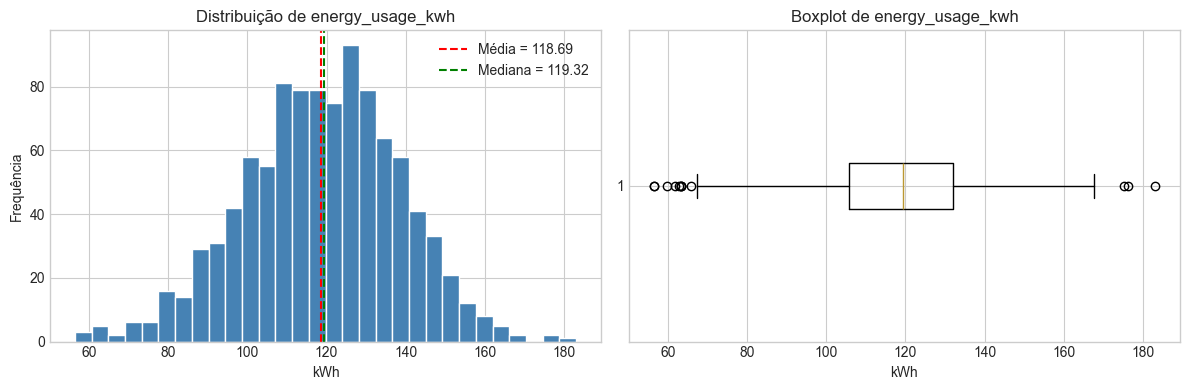

📊 Estatísticas do alvo:
count    1000.00
mean      118.69
std        19.74
min        56.47
25%       105.88
50%       119.32
75%       131.96
max       183.04
Name: energy_usage_kwh, dtype: float64

💡 Assimetria (skew): -0.183  (≈0 = simétrico)


In [6]:
# ============================================================
# 4.1 — DISTRIBUIÇÃO DO ALVO (energy_usage_kwh)
# ============================================================

TARGET = "energy_usage_kwh"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df[TARGET], bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--",
                label=f"Média = {df[TARGET].mean():.2f}")
axes[0].axvline(df[TARGET].median(), color="green", linestyle="--",
                label=f"Mediana = {df[TARGET].median():.2f}")
axes[0].set_title(f"Distribuição de {TARGET}")
axes[0].set_xlabel("kWh")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Boxplot
axes[1].boxplot(df[TARGET], vert=False)
axes[1].set_title(f"Boxplot de {TARGET}")
axes[1].set_xlabel("kWh")

plt.tight_layout()
plt.savefig("distribuicao_target.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"📊 Estatísticas do alvo:")
print(df[TARGET].describe().round(2))
print(f"\n💡 Assimetria (skew): {df[TARGET].skew():.3f}  (≈0 = simétrico)")


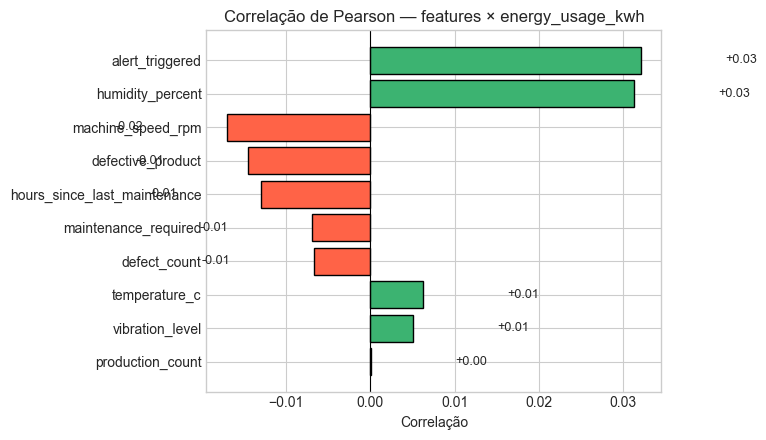

📊 Correlação com o alvo (ordem de |corr|):
alert_triggered                 0.032
humidity_percent                0.031
machine_speed_rpm              -0.017
defective_product              -0.015
hours_since_last_maintenance   -0.013
maintenance_required           -0.007
defect_count                   -0.007
temperature_c                   0.006
vibration_level                 0.005
production_count                0.000
Name: energy_usage_kwh, dtype: float64


In [7]:
# ============================================================
# 4.2 — CORRELAÇÃO DAS FEATURES COM O ALVO
# ============================================================
# Calculamos a correlação de Pearson entre cada feature e o alvo.
# Valores próximos de +1 ou -1 indicam forte relação linear.

corr_target = (
    df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["tomato" if v < 0 else "mediumseagreen" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Correlação de Pearson — features × {TARGET}")
ax.set_xlabel("Correlação")
ax.invert_yaxis()

for i, v in enumerate(corr_target.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig("correlacao_features_target.png", dpi=100, bbox_inches="tight")
plt.show()

print("📊 Correlação com o alvo (ordem de |corr|):")
print(corr_target.round(3))


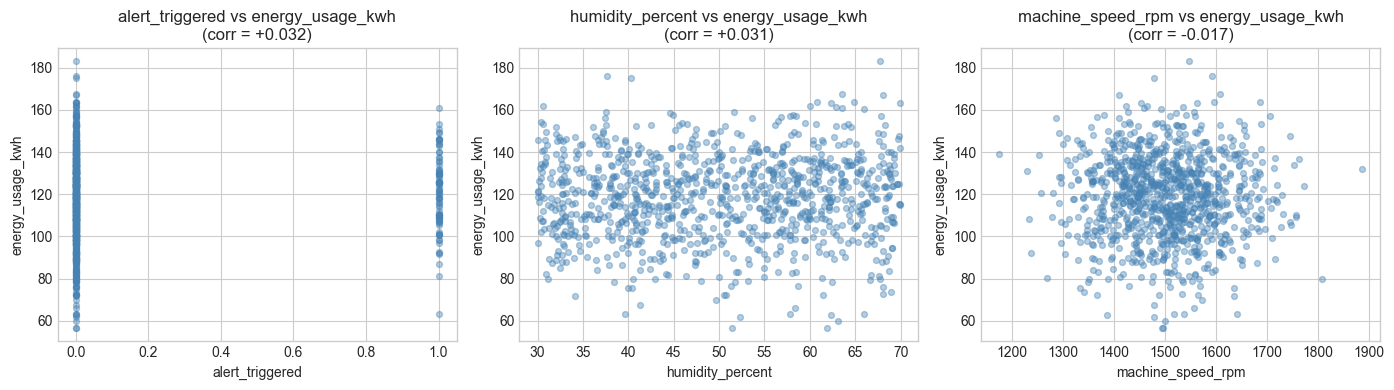

💡 As 3 features mais correlacionadas com o alvo são: ['alert_triggered', 'humidity_percent', 'machine_speed_rpm']


In [8]:
# ============================================================
# 4.3 — SCATTER DAS 3 FEATURES MAIS CORRELACIONADAS COM O ALVO
# ============================================================
# Um gráfico de dispersão revela padrões que a correlação sozinha
# não mostra (não-linearidades, clusters, heterocedasticidade).

top3 = corr_target.abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df[TARGET], alpha=0.4, s=18, color="steelblue")
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    ax.set_title(f"{feat} vs {TARGET}\n(corr = {corr_target[feat]:+.3f})")

plt.tight_layout()
plt.savefig("scatter_top_features.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"💡 As 3 features mais correlacionadas com o alvo são: {top3}")


## 5️⃣ Split Treino/Teste + Pipeline sklearn

Duas boas práticas que vamos usar juntas aqui:

### 5.1 `train_test_split`
Separamos os dados em **treino (80%)** e **teste (20%)**. O teste **nunca** é usado para treinar — só serve para avaliar o modelo final, simulando dados "do futuro".

### 5.2 `Pipeline` + `ColumnTransformer`
Um `Pipeline` é uma "fila" de transformações + modelo que se comporta como **um único estimador**. Isso traz duas vantagens gigantes:

1. **Evita data leakage**: o `StandardScaler` aprende a média/desvio **apenas** no treino, e depois aplica no teste.
2. **Simplifica o deploy**: basta salvar o pipeline (`joblib`) e `pipeline.predict(novo_dado)` já faz scaling + previsão.

```
┌─────────────────────── Pipeline ───────────────────────┐
│  SimpleImputer  →  StandardScaler  →  Regressor         │
│  (preencher    )   (padronizar   )   (prever alvo     )  │
└─────────────────────────────────────────────────────────┘
```

> 💡 Nosso dataset não tem nulos, mas mantemos o `SimpleImputer` no pipeline — é uma rede de segurança para quando chegarem dados novos em produção.


In [9]:
# ============================================================
# SEPARAÇÃO FEATURES (X) E ALVO (y) + TRAIN/TEST SPLIT
# ============================================================

feature_names = [c for c in df.columns if c != TARGET]
X = df[feature_names].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"🎯 Alvo: {TARGET}")
print(f"📐 Features ({len(feature_names)}): {feature_names}")
print(f"\n📦 Treino: X={X_train.shape}, y={y_train.shape}")
print(f"📦 Teste : X={X_test.shape}, y={y_test.shape}")
print(f"\n💰 Média do alvo no treino: {y_train.mean():.2f} kWh")
print(f"💰 Média do alvo no teste : {y_test.mean():.2f} kWh")


🎯 Alvo: energy_usage_kwh
📐 Features (10): ['machine_speed_rpm', 'temperature_c', 'humidity_percent', 'vibration_level', 'production_count', 'defect_count', 'hours_since_last_maintenance', 'maintenance_required', 'alert_triggered', 'defective_product']

📦 Treino: X=(800, 10), y=(800,)
📦 Teste : X=(200, 10), y=(200,)

💰 Média do alvo no treino: 118.97 kWh
💰 Média do alvo no teste : 117.58 kWh


In [ ]:
# ============================================================
# CONSTRUÇÃO DO PRÉ-PROCESSADOR COM ColumnTransformer
# ============================================================
# Todas as nossas features são numéricas, mas usar ColumnTransformer
# deixa o código pronto para receber colunas categóricas no futuro
# (basta adicionar outra "pipeline" para cat_cols).

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  # preenche nulos com mediana
    ("scaler",  StandardScaler()),                  # padroniza (média 0, desvio 1)
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_cols),
])

print(f"✅ Pré-processador pronto para {len(num_cols)} colunas numéricas.")
print(f"   Steps: Imputer(median) → StandardScaler")


✅ Pré-processador pronto para 10 colunas numéricas.
   Steps: Imputer(median) → StandardScaler


## 6️⃣ Métricas de Regressão — Como Medir Acerto?

Em classificação medimos acurácia, F1, etc. Em **regressão** precisamos medir "o quão perto a previsão ficou do valor real". As 4 métricas mais usadas:

| Métrica | Fórmula (intuitiva) | Unidade | Interpretação |
|---|---|---|---|
| **R²** | quanto da variância do alvo o modelo explica | adimensional (0 a 1) | 1.0 = perfeito · 0.0 = igual à média · < 0 = pior que a média |
| **MAE** | média de `\|previsto − real\|` | mesma do alvo (kWh) | Fácil de explicar para a área de negócio |
| **RMSE** | √ média dos erros² | mesma do alvo (kWh) | Penaliza mais os erros grandes |
| **MAPE** | média de `\|erro / real\|` | percentual | Útil para comparar alvos em escalas diferentes |

Vamos criar uma função utilitária `avaliar_regressor()` que calcula todas essas métricas e já loga tudo no MLflow — assim ficamos DRY (don't repeat yourself) entre todos os modelos.


In [12]:
# ============================================================
# FUNÇÕES UTILITÁRIAS — MÉTRICAS, PLOTS E LOG NO MLFLOW
# ============================================================

def calcular_metricas(y_true, y_pred):
    """Calcula R², MAE, RMSE e MAPE e devolve em um dicionário."""
    return {
        "r2":   r2_score(y_true, y_pred),
        "mae":  mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
    }


def plot_predicted_vs_actual(y_true, y_pred, titulo, salvar_em=None):
    """Plota previsto vs real + resíduos. Retorna a figura (para MLflow)."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Gráfico 1: previsto vs real
    axes[0].scatter(y_true, y_pred, alpha=0.5, s=20, color="steelblue")
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1.5, label="Previsão perfeita")
    axes[0].set_xlabel("Real (kWh)")
    axes[0].set_ylabel("Previsto (kWh)")
    axes[0].set_title(f"{titulo} — Previsto vs Real")
    axes[0].legend()

    # Gráfico 2: resíduos (erro = real − previsto)
    residuos = y_true - y_pred
    axes[1].scatter(y_pred, residuos, alpha=0.5, s=20, color="darkorange")
    axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
    axes[1].set_xlabel("Previsto (kWh)")
    axes[1].set_ylabel("Resíduo (real − previsto)")
    axes[1].set_title(f"{titulo} — Resíduos")

    plt.tight_layout()
    if salvar_em:
        plt.savefig(salvar_em, dpi=100, bbox_inches="tight")
    return fig


def treinar_e_avaliar(nome_modelo, estimator, params_extras=None, log_mlflow=True):
    """Treina um Pipeline (preprocessor + estimator), avalia no teste,
    plota e (opcional) loga tudo no MLflow. Devolve um dict com resultados."""
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor",    estimator),
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    tempo_treino = time.time() - t0

    y_pred = pipe.predict(X_test)
    metricas = calcular_metricas(y_test, y_pred)

    print(f"📊 {nome_modelo}")
    print(f"   R²  = {metricas['r2']:+.4f}")
    print(f"   MAE = {metricas['mae']:.3f} kWh")
    print(f"   RMSE= {metricas['rmse']:.3f} kWh")
    print(f"   MAPE= {metricas['mape']*100:.2f}%")
    print(f"   ⏱️  Treino: {tempo_treino:.2f}s")

    fig_path = f"pred_vs_real_{nome_modelo}.png"
    fig = plot_predicted_vs_actual(y_test, y_pred, nome_modelo, salvar_em=fig_path)
    plt.show()

    if log_mlflow:
        with mlflow.start_run(run_name=nome_modelo):
            # Parâmetros do estimador interno (evita poluir com o preprocessor)
            try:
                mlflow.log_params(estimator.get_params(deep=False))
            except Exception:
                pass
            if params_extras:
                mlflow.log_params(params_extras)
            mlflow.log_metrics(metricas)
            mlflow.log_metric("tempo_treino_s", tempo_treino)
            mlflow.log_artifact(fig_path, "plots")
            # Loga o pipeline inteiro como modelo
            mlflow.sklearn.log_model(pipe, name="model")

    return {
        "nome": nome_modelo,
        "pipeline": pipe,
        "metricas": metricas,
        "tempo_treino_s": tempo_treino,
    }


print("✅ Utilitários prontos: calcular_metricas, plot_predicted_vs_actual, treinar_e_avaliar")


✅ Utilitários prontos: calcular_metricas, plot_predicted_vs_actual, treinar_e_avaliar


## 7️⃣ Treinamento dos Modelos de Regressão

Agora vamos treinar, na sequência, 6 regressores diferentes. Para cada um:

- Encapsulamos o estimador em um `Pipeline` (preprocessor + regressor);
- Treinamos no conjunto de treino;
- Avaliamos no conjunto de teste (R², MAE, RMSE, MAPE);
- Plotamos previsto × real e resíduos;
- Registramos tudo como um **run** no MLflow.

```
📚 Família Linear      📚 Não-lineares
├── LinearRegression   ├── SVR (RBF)
├── Ridge              └── XGBRegressor
├── Lasso
└── ElasticNet
```

> 💡 Dica conceitual: **Ridge, Lasso e ElasticNet** são variações da regressão linear com diferentes formas de **regularização** (penalidade em coeficientes grandes), úteis para evitar overfitting quando há muitas features correlacionadas.


📊 LinearRegression_baseline
   R²  = -0.0157
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.02s


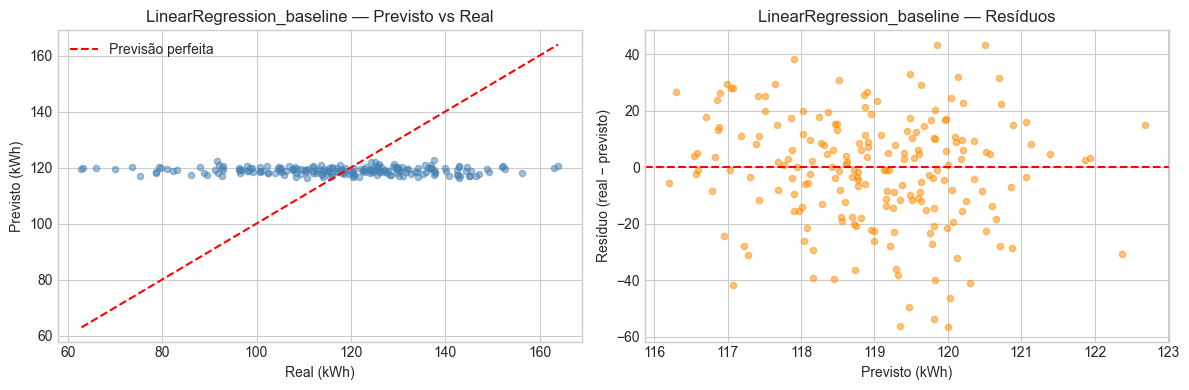

2026/04/27 20:20:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [13]:
# ============================================================
# 7.1 — LINEAR REGRESSION (BASELINE)
# ============================================================
# É o modelo mais simples possível. Serve como "linha de base":
# qualquer modelo mais sofisticado precisa superá-lo para justificar
# sua complexidade extra.

resultados_todos = []

resultado_lr = treinar_e_avaliar(
    nome_modelo="LinearRegression_baseline",
    estimator=LinearRegression(),
)
resultados_todos.append(resultado_lr)


📊 Ridge_alpha1
   R²  = -0.0156
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


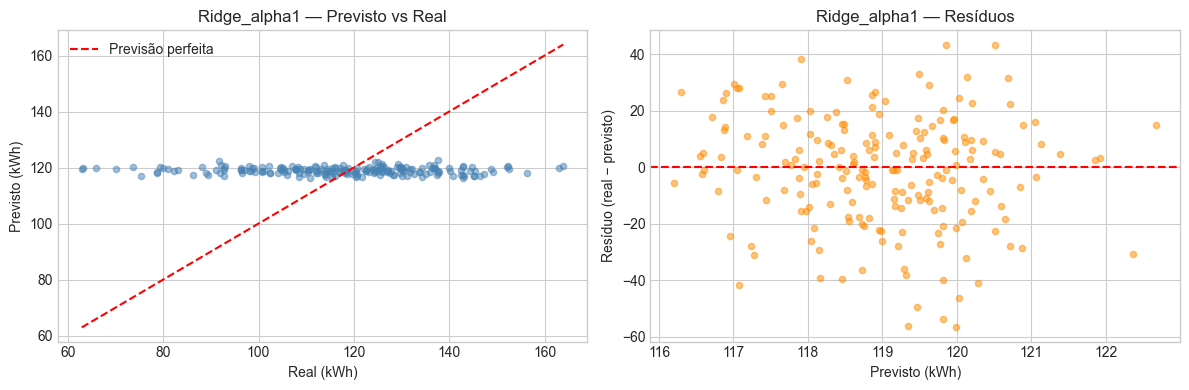

2026/04/27 20:20:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [14]:
# ============================================================
# 7.2 — RIDGE (L2)
# ============================================================
# Ridge = LinearRegression + penalidade L2 nos coeficientes.
# "alpha" controla a força da penalidade: maior alpha = coeficientes
# menores (modelo mais "suave"), menor alpha ≈ LinearRegression.

resultado_ridge = treinar_e_avaliar(
    nome_modelo="Ridge_alpha1",
    estimator=Ridge(alpha=1.0, random_state=RANDOM_STATE),
)
resultados_todos.append(resultado_ridge)


📊 Lasso_alpha01
   R²  = -0.0099
   MAE = 15.348 kWh
   RMSE= 19.530 kWh
   MAPE= 14.47%
   ⏱️  Treino: 0.01s


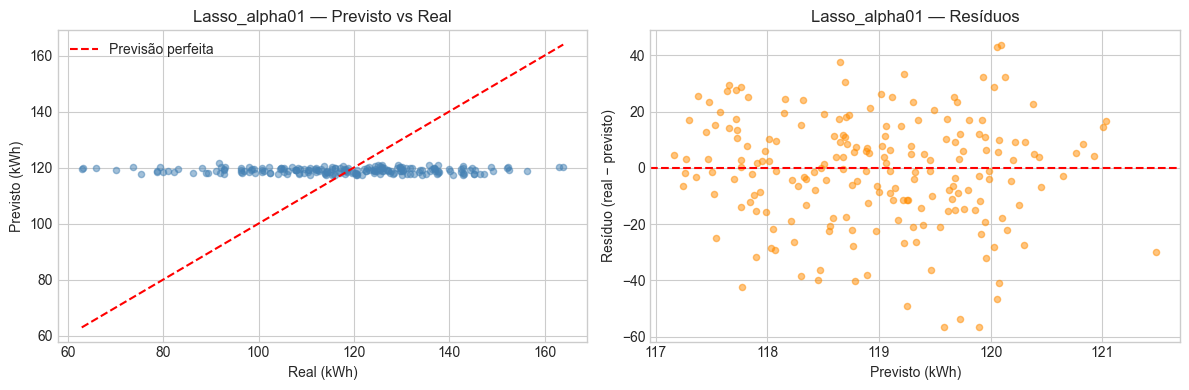

2026/04/27 20:21:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [15]:
# ============================================================
# 7.3 — LASSO (L1)
# ============================================================
# Lasso = LinearRegression + penalidade L1.
# Diferencial do Lasso: pode ZERAR coeficientes de features
# irrelevantes — ou seja, faz seleção automática de features.

resultado_lasso = treinar_e_avaliar(
    nome_modelo="Lasso_alpha01",
    estimator=Lasso(alpha=0.1, random_state=RANDOM_STATE, max_iter=10000),
)
resultados_todos.append(resultado_lasso)


📊 ElasticNet_alpha01_l105
   R²  = -0.0117
   MAE = 15.353 kWh
   RMSE= 19.547 kWh
   MAPE= 14.47%
   ⏱️  Treino: 0.01s


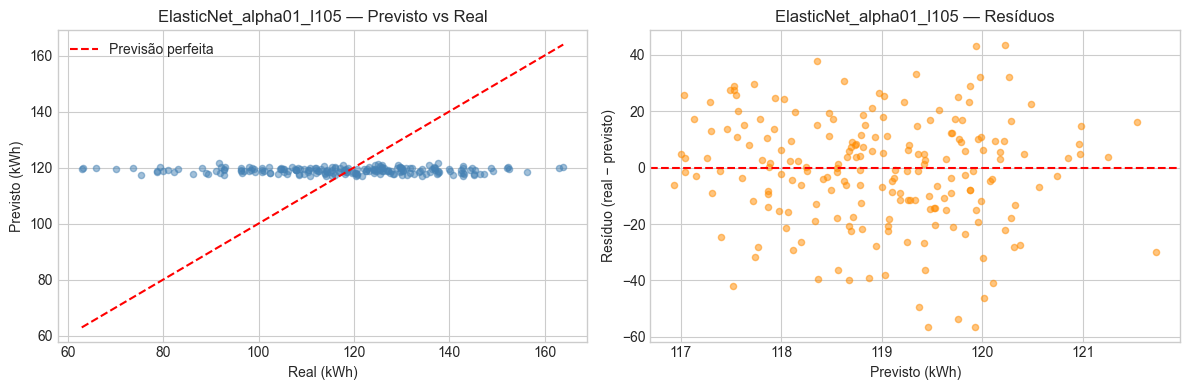

2026/04/27 20:21:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [16]:
# ============================================================
# 7.4 — ELASTIC NET (L1 + L2)
# ============================================================
# ElasticNet combina Ridge (L2) e Lasso (L1).
# "l1_ratio" pondera a mistura: 0 = só Ridge, 1 = só Lasso,
# 0.5 = meio a meio (equilíbrio entre estabilidade e seleção).

resultado_enet = treinar_e_avaliar(
    nome_modelo="ElasticNet_alpha01_l105",
    estimator=ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=10000),
)
resultados_todos.append(resultado_enet)


📊 SVR_rbf
   R²  = -0.0226
   MAE = 15.323 kWh
   RMSE= 19.652 kWh
   MAPE= 14.59%
   ⏱️  Treino: 0.02s


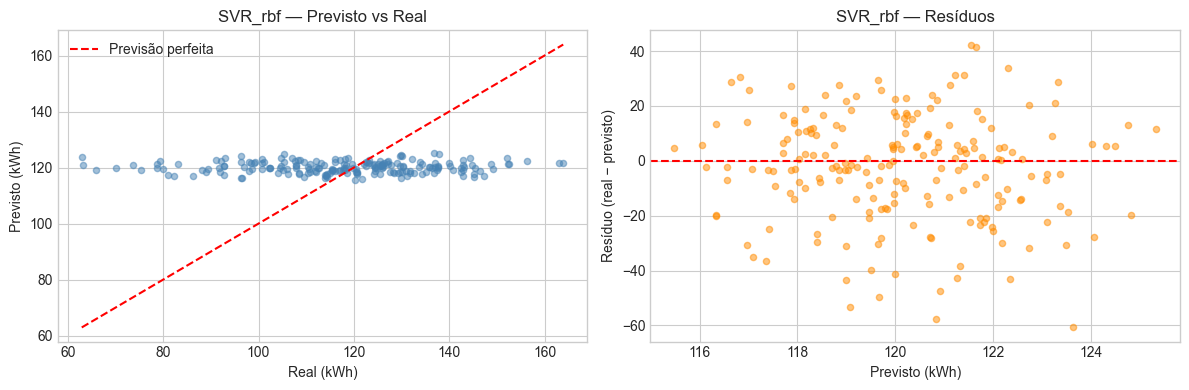

2026/04/27 20:21:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [17]:
# ============================================================
# 7.5 — SVR (Support Vector Regression)
# ============================================================
# A versão "regressora" do SVM da Aula 2. Com kernel RBF consegue
# capturar relações NÃO LINEARES entre features e alvo.
# Depende fortemente do scaling — que o nosso Pipeline já faz.

resultado_svr = treinar_e_avaliar(
    nome_modelo="SVR_rbf",
    estimator=SVR(kernel="rbf", C=1.0, epsilon=0.1),
)
resultados_todos.append(resultado_svr)


📊 XGBRegressor_baseline
   R²  = -0.2244
   MAE = 16.988 kWh
   RMSE= 21.504 kWh
   MAPE= 15.95%
   ⏱️  Treino: 0.52s


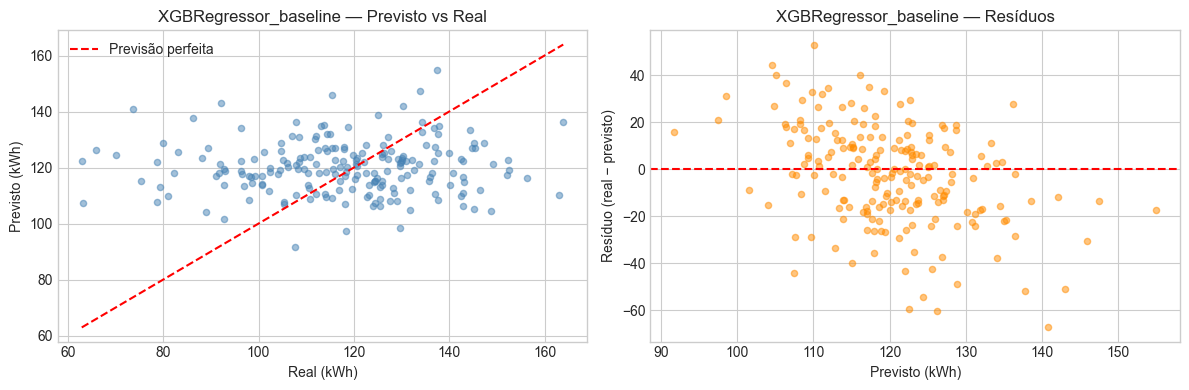

2026/04/27 20:21:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
# ============================================================
# 7.6 — XGBOOST REGRESSOR (BASELINE)
# ============================================================
# Gradient Boosting de árvores (mesmo algoritmo da Aula 2,
# agora com saída contínua). Costuma ser competitivo mesmo com
# hiperparâmetros padrão.

resultado_xgb = treinar_e_avaliar(
    nome_modelo="XGBRegressor_baseline",
    estimator=xgb.XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
    ),
)




resultados_todos.append(resultado_xgb)


## 8️⃣ Comparação Consolidada dos Modelos Base

Depois de treinar todos, vamos comparar as métricas lado a lado. Cada métrica conta uma parte da história:

- Quem explica melhor a variância? → **maior R²**
- Quem erra menos em média? → **menor MAE**
- Quem controla melhor erros grandes? → **menor RMSE**
- Quem erra menos percentualmente? → **menor MAPE**


In [19]:
# ============================================================
# TABELA DE COMPARAÇÃO ENTRE OS MODELOS BASE
# ============================================================

df_resultados = pd.DataFrame([
    {
        "modelo": r["nome"],
        "R2":    r["metricas"]["r2"],
        "MAE":   r["metricas"]["mae"],
        "RMSE":  r["metricas"]["rmse"],
        "MAPE%": r["metricas"]["mape"] * 100,
        "tempo_s": r["tempo_treino_s"],
    }
    for r in resultados_todos
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("🏆 Ranking dos modelos base (ordenado por R²):\n")
print(df_resultados.round(4).to_string(index=False))

# Salva um CSV consolidado (bom para o MLflow e para o aluno consultar depois)
df_resultados.to_csv("resultados_aula03.csv", index=False)


🏆 Ranking dos modelos base (ordenado por R²):

                   modelo      R2     MAE    RMSE   MAPE%  tempo_s
            Lasso_alpha01 -0.0099 15.3479 19.5297 14.4662   0.0081
  ElasticNet_alpha01_l105 -0.0117 15.3527 19.5470 14.4709   0.0073
             Ridge_alpha1 -0.0156 15.3629 19.5848 14.4813   0.0093
LinearRegression_baseline -0.0157 15.3630 19.5852 14.4814   0.0178
                  SVR_rbf -0.0226 15.3232 19.6515 14.5921   0.0233
    XGBRegressor_baseline -0.2244 16.9882 21.5039 15.9481   0.5172


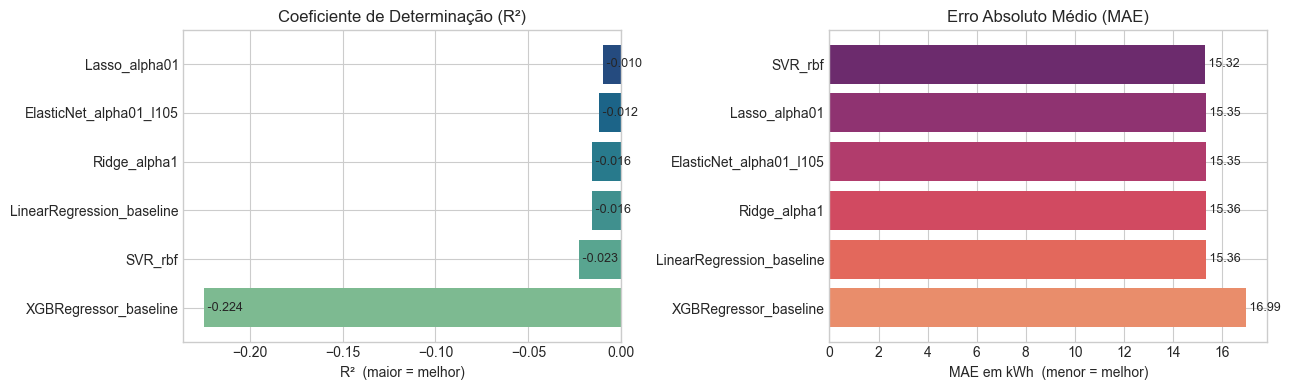

In [20]:
# ============================================================
# VISUALIZAÇÃO DO RANKING (R² e MAE lado a lado)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# R² — quanto maior, melhor
ordem_r2 = df_resultados.sort_values("R2", ascending=True)
axes[0].barh(ordem_r2["modelo"], ordem_r2["R2"],
             color=sns.color_palette("crest", len(ordem_r2)))
axes[0].set_xlabel("R²  (maior = melhor)")
axes[0].set_title("Coeficiente de Determinação (R²)")
for i, v in enumerate(ordem_r2["R2"].values):
    axes[0].text(v, i, f" {v:+.3f}", va="center", fontsize=9)

# MAE — quanto menor, melhor
ordem_mae = df_resultados.sort_values("MAE", ascending=False)
axes[1].barh(ordem_mae["modelo"], ordem_mae["MAE"],
             color=sns.color_palette("flare", len(ordem_mae)))
axes[1].set_xlabel("MAE em kWh  (menor = melhor)")
axes[1].set_title("Erro Absoluto Médio (MAE)")
for i, v in enumerate(ordem_mae["MAE"].values):
    axes[1].text(v, i, f" {v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("ranking_modelos.png", dpi=100, bbox_inches="tight")
plt.show()


## 9️⃣ Otimização Bayesiana com Optuna

Na Aula 2 usamos `GridSearchCV` (busca em todas as combinações) e `RandomizedSearchCV` (amostragem aleatória). Agora vamos um passo adiante com **Optuna**, que usa **otimização bayesiana**:

> A ideia: em vez de testar aleatoriamente, o Optuna usa os resultados das tentativas anteriores para **escolher combinações que têm maior chance de serem melhores**. É como um "cientista" aprendendo a cada experimento.

### Fluxo com Optuna

```
┌─ study ──────────────────────────────────────────────┐
│  trial 1: hiperparâmetros aleatórios  → score        │
│  trial 2: usa trial 1 para sugerir próximo  → score  │
│  trial 3: usa 1+2 para sugerir próximo    → score    │
│  ...                                                  │
│  trial N: retorna melhor combinação encontrada       │
└───────────────────────────────────────────────────────┘
```

Cada trial vira um **nested run** dentro de um run "pai" no MLflow — assim comparamos facilmente todas as tentativas.

> ⏱️ Para manter a aula ágil, vamos rodar apenas `N_TRIALS = 25` trials. Em um projeto real, use 100+.


In [21]:
# ============================================================
# DEFINIÇÃO DA FUNÇÃO OBJETIVO DO OPTUNA
# ============================================================
# O Optuna chama essa função N vezes. Em cada chamada, ele sugere
# um conjunto de hiperparâmetros e a função devolve um "score"
# (aqui usamos a média de R² em 5-fold cross-validation).
# O Optuna tenta MAXIMIZAR esse score.

N_TRIALS = 25  # Aumente para 100+ em projetos reais

def objetivo_xgb(trial):
    # Espaço de busca: o Optuna vai navegar dentro desses intervalos
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 1.0, log=True),
    }

    # Montamos o Pipeline com os hiperparâmetros sugeridos neste trial
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor",    xgb.XGBRegressor(
            **params,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            verbosity=0,
        )),
    ])

    # 5-fold CV no treino — protege contra "sorte" em um split específico
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train,
                             scoring="r2", cv=kf, n_jobs=-1)
    r2_medio = scores.mean()

    # Loga o trial como um nested run no MLflow
    with mlflow.start_run(run_name=f"xgb_trial_{trial.number:02d}", nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("cv_r2_mean", r2_medio)
        mlflow.log_metric("cv_r2_std",  scores.std())

    return r2_medio


print(f"✅ Função objetivo definida (espaço de 7 hiperparâmetros).")
print(f"   Vamos rodar {N_TRIALS} trials com 5-fold CV cada.")


✅ Função objetivo definida (espaço de 7 hiperparâmetros).
   Vamos rodar 25 trials com 5-fold CV cada.


In [22]:
# ============================================================
# EXECUÇÃO DO OPTUNA (dentro de um run "pai" no MLflow)
# ============================================================

with mlflow.start_run(run_name="XGBRegressor_Optuna"):
    mlflow.log_param("n_trials", N_TRIALS)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("scoring", "r2")

    # TPESampler é o algoritmo bayesiano padrão do Optuna
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_STATE),
        study_name="xgb_regressao_producao",
    )

    t0 = time.time()
    study.optimize(objetivo_xgb, n_trials=N_TRIALS, show_progress_bar=False)
    tempo_optuna = time.time() - t0

    # Loga os melhores hiperparâmetros e o score no run pai
    mlflow.log_params({f"best_{k}": v for k, v in study.best_params.items()})
    mlflow.log_metric("best_cv_r2", study.best_value)
    mlflow.log_metric("tempo_total_s", tempo_optuna)

print(f"\n⏱️  Tempo total do Optuna: {tempo_optuna:.1f}s ({N_TRIALS} trials)")
print(f"🏆 Melhor R² (CV): {study.best_value:.4f}")
print(f"🏆 Melhores hiperparâmetros:")
for k, v in study.best_params.items():
    print(f"   {k} = {v}")



⏱️  Tempo total do Optuna: 19.7s (25 trials)
🏆 Melhor R² (CV): -0.0066
🏆 Melhores hiperparâmetros:
   n_estimators = 100
   max_depth = 3
   learning_rate = 0.010062398199712276
   subsample = 0.6850930305164684
   colsample_bytree = 0.7274512802575641
   reg_alpha = 0.04504283471078713
   reg_lambda = 0.23764047229894186


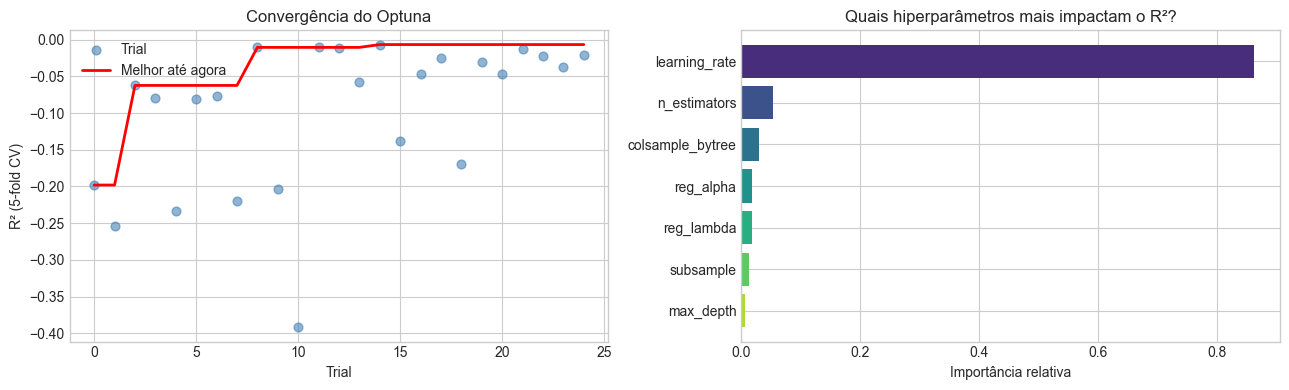

In [23]:
# ============================================================
# VISUALIZAÇÕES DA CONVERGÊNCIA DO OPTUNA
# ============================================================
# 1) Evolução do melhor score ao longo dos trials
# 2) Importância relativa de cada hiperparâmetro

df_trials = study.trials_dataframe()[["number", "value", "state"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: R² ao longo dos trials + "best so far"
axes[0].scatter(df_trials["number"], df_trials["value"],
                alpha=0.6, s=40, color="steelblue", label="Trial")
best_so_far = df_trials["value"].cummax()
axes[0].plot(df_trials["number"], best_so_far, color="red",
             linewidth=2, label="Melhor até agora")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("R² (5-fold CV)")
axes[0].set_title("Convergência do Optuna")
axes[0].legend()

# Gráfico 2: importância dos hiperparâmetros
try:
    importancias = optuna.importance.get_param_importances(study)
    nomes = list(importancias.keys())
    vals  = list(importancias.values())
    axes[1].barh(nomes, vals, color=sns.color_palette("viridis", len(nomes)))
    axes[1].set_xlabel("Importância relativa")
    axes[1].set_title("Quais hiperparâmetros mais impactam o R²?")
    axes[1].invert_yaxis()
except Exception as e:
    axes[1].text(0.5, 0.5, f"Importâncias indisponíveis\n({e})",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig("optuna_convergencia.png", dpi=100, bbox_inches="tight")
plt.show()


📊 XGBRegressor_Optuna_best
   R²  = -0.0161
   MAE = 15.404 kWh
   RMSE= 19.590 kWh
   MAPE= 14.52%
   ⏱️  Treino: 0.07s


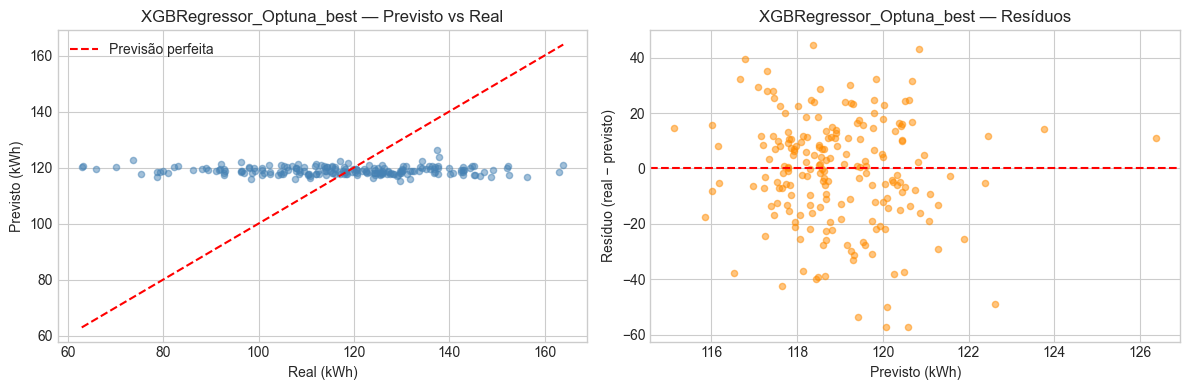

2026/04/27 20:28:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



🏆 Ranking ATUALIZADO (com o XGB otimizado pelo Optuna):

                   modelo      R2     MAE    RMSE   MAPE%  tempo_s
            Lasso_alpha01 -0.0099 15.3479 19.5297 14.4662   0.0081
  ElasticNet_alpha01_l105 -0.0117 15.3527 19.5470 14.4709   0.0073
             Ridge_alpha1 -0.0156 15.3629 19.5848 14.4813   0.0093
LinearRegression_baseline -0.0157 15.3630 19.5852 14.4814   0.0178
 XGBRegressor_Optuna_best -0.0161 15.4043 19.5898 14.5206   0.0660
                  SVR_rbf -0.0226 15.3232 19.6515 14.5921   0.0233
    XGBRegressor_baseline -0.2244 16.9882 21.5039 15.9481   0.5172


In [24]:
# ============================================================
# TREINA O MELHOR XGBRegressor ENCONTRADO E AVALIA NO TESTE
# ============================================================

melhor_xgb = xgb.XGBRegressor(
    **study.best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
    verbosity=0,
)

resultado_xgb_optuna = treinar_e_avaliar(
    nome_modelo="XGBRegressor_Optuna_best",
    estimator=melhor_xgb,
    params_extras={"n_trials": N_TRIALS},
)
resultados_todos.append(resultado_xgb_optuna)

# Refaz a tabela de comparação
df_resultados = pd.DataFrame([
    {
        "modelo": r["nome"],
        "R2":    r["metricas"]["r2"],
        "MAE":   r["metricas"]["mae"],
        "RMSE":  r["metricas"]["rmse"],
        "MAPE%": r["metricas"]["mape"] * 100,
        "tempo_s": r["tempo_treino_s"],
    }
    for r in resultados_todos
]).sort_values("R2", ascending=False).reset_index(drop=True)

print("\n🏆 Ranking ATUALIZADO (com o XGB otimizado pelo Optuna):\n")
print(df_resultados.round(4).to_string(index=False))
df_resultados.to_csv("resultados_aula03.csv", index=False)


## 🔟 Interpretabilidade com SHAP

Ter um modelo que acerta muito não basta — na indústria, engenheiros e gestores querem saber **POR QUE** o modelo prevê o que prevê. É aqui que entra o **SHAP (SHapley Additive exPlanations)**:

> Para **cada previsão**, o SHAP atribui um "peso" a cada feature, mostrando o quanto ela contribuiu para empurrar a previsão **para cima ou para baixo** em relação à média.

### Dois níveis de análise

1. **Global** — quais features mais impactam o modelo em média? (gráfico de barras com `mean(|SHAP|)`)
2. **Local** — por que o modelo previu X kWh para uma amostra específica? (beeswarm ou waterfall)

Vamos explicar o **XGB Optuna_best** — nosso melhor modelo até aqui.


In [25]:
# ============================================================
# CÁLCULO DOS SHAP VALUES NO MELHOR MODELO
# ============================================================
# O SHAP precisa do modelo "puro" (sem o Pipeline), então extraímos
# o XGBRegressor de dentro do Pipeline e alimentamos com os dados
# já transformados pelo preprocessor.

pipe_best = resultado_xgb_optuna["pipeline"]
modelo_final = pipe_best.named_steps["regressor"]
X_test_transf = pipe_best.named_steps["preprocessor"].transform(X_test)

# Envolvemos em DataFrame para preservar os nomes das features nos plots
X_test_transf = pd.DataFrame(X_test_transf, columns=feature_names, index=X_test.index)

# TreeExplainer é otimizado para modelos baseados em árvores (XGBoost, LightGBM, RF)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test_transf)

print(f"✅ SHAP values calculados para {X_test_transf.shape[0]} amostras "
      f"× {X_test_transf.shape[1]} features.")


✅ SHAP values calculados para 200 amostras × 10 features.


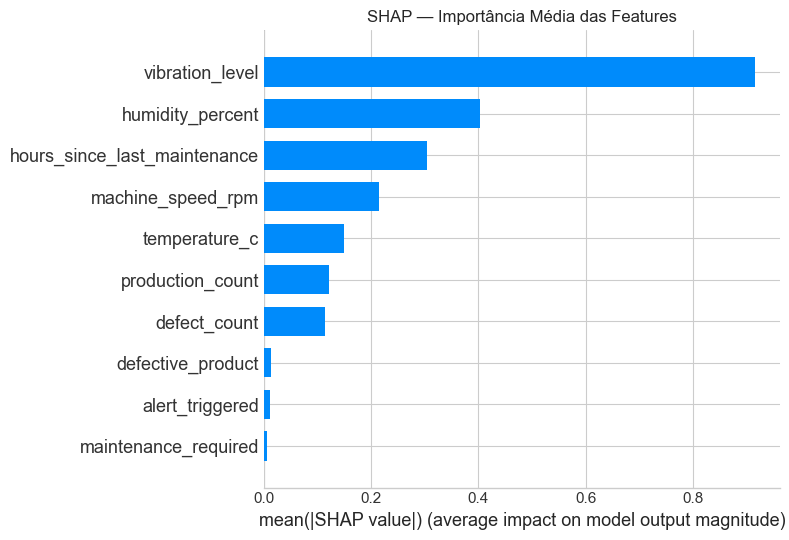

In [26]:
# ============================================================
# INTERPRETAÇÃO GLOBAL — IMPORTÂNCIA MÉDIA DAS FEATURES
# ============================================================
# O gráfico de barras mostra mean(|SHAP|) por feature:
# quanto maior, mais importante a feature foi (em média) para o modelo.

plt.figure()
shap.summary_plot(shap_values, X_test_transf, plot_type="bar", show=False)
plt.title("SHAP — Importância Média das Features", fontsize=12)
plt.tight_layout()
plt.savefig("shap_global_bar.png", dpi=100, bbox_inches="tight")
plt.show()


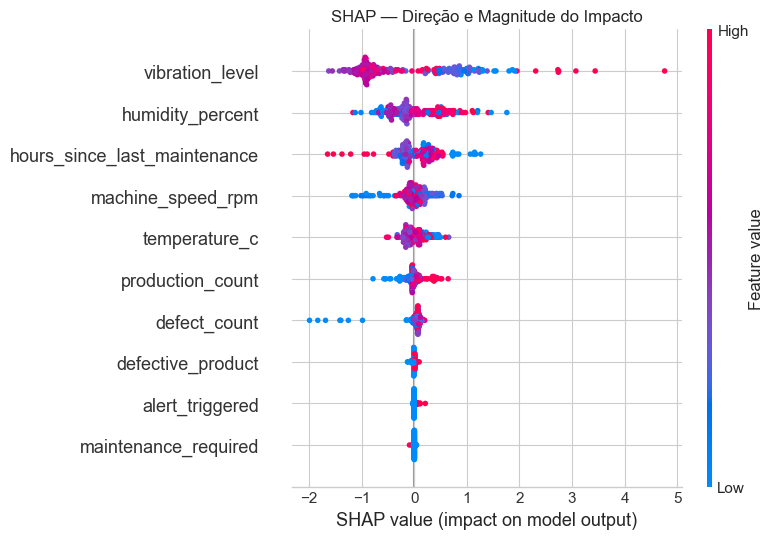

In [27]:
# ============================================================
# INTERPRETAÇÃO GLOBAL — BEESWARM
# ============================================================
# Cada ponto é UMA amostra. Posição horizontal = impacto no valor
# previsto. Cor = valor da feature (vermelho = alto, azul = baixo).
# Isso revela a DIREÇÃO do efeito (feature X alta aumenta ou diminui
# o consumo previsto?), que o gráfico de barras não mostra.

plt.figure()
shap.summary_plot(shap_values, X_test_transf, show=False)
plt.title("SHAP — Direção e Magnitude do Impacto", fontsize=12)
plt.tight_layout()
plt.savefig("shap_global_beeswarm.png", dpi=100, bbox_inches="tight")
plt.show()


🔍 Amostra #0 do teste:
   Valor real:     142.56 kWh
   Valor previsto: 119.30 kWh
   Erro:           -23.26 kWh



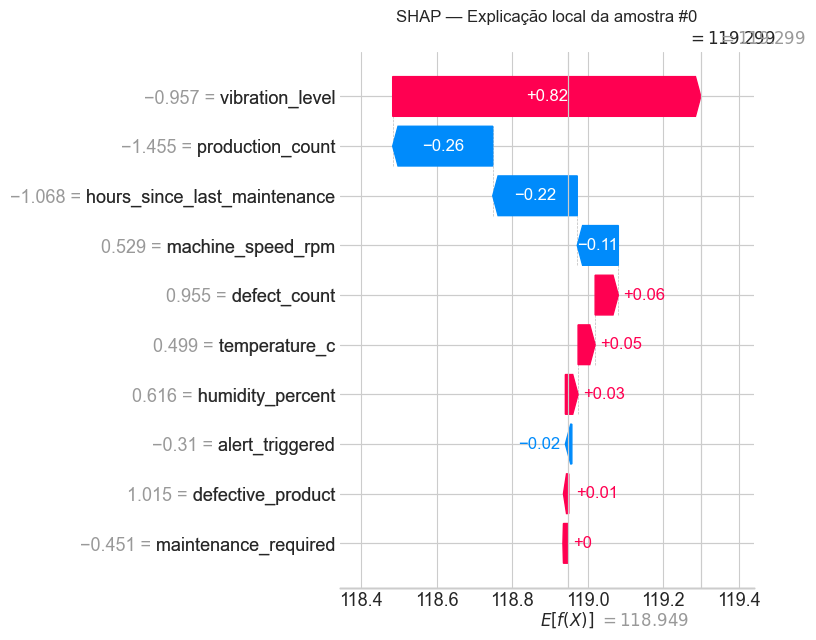

In [28]:
# ============================================================
# INTERPRETAÇÃO LOCAL — POR QUE O MODELO PREVIU X PARA ESTA AMOSTRA?
# ============================================================
# Waterfall plot: parte do valor "esperado" (média das previsões)
# e mostra como CADA feature empurrou para cima/para baixo até
# chegar na previsão final desta amostra específica.

idx_amostra = 0  # escolhemos a primeira amostra do teste
valor_real     = y_test.iloc[idx_amostra]
valor_previsto = pipe_best.predict(X_test.iloc[[idx_amostra]])[0]

print(f"🔍 Amostra #{idx_amostra} do teste:")
print(f"   Valor real:     {valor_real:.2f} kWh")
print(f"   Valor previsto: {valor_previsto:.2f} kWh")
print(f"   Erro:           {valor_previsto - valor_real:+.2f} kWh\n")

# Monta a Explanation para o waterfall
explanation_amostra = shap.Explanation(
    values=shap_values[idx_amostra],
    base_values=explainer.expected_value,
    data=X_test_transf.iloc[idx_amostra].values,
    feature_names=feature_names,
)

plt.figure()
shap.plots.waterfall(explanation_amostra, show=False)
plt.title(f"SHAP — Explicação local da amostra #{idx_amostra}", fontsize=12)
plt.tight_layout()
plt.savefig("shap_local_waterfall.png", dpi=100, bbox_inches="tight")
plt.show()


## 1️⃣1️⃣ Exportação dos Modelos para Versionamento

Agora salvamos todos os pipelines treinados em `../modelos/aula03/` com nomenclatura padronizada entre todas as aulas:

```
modelos/aula03/<algoritmo>_<variante>_producao_textil_v1.joblib
```

Essa convenção permite:

- **Identificar** rapidamente a qual aula pertence o modelo (`modelos/aula03/...`);
- **Comparar** variantes (`lr_baseline`, `ridge_alpha1`, `xgb_optuna_best`, ...);
- **Versionar** com bump fácil (`_v1`, `_v2`) quando retreinar no futuro;
- Servir como insumo para a **Aula 9 (FastAPI + MLflow Model Registry)**, onde vamos registrar esses modelos para deploy.

Também exportamos a lista de `features` e o `scaler` — importantes para garantir que dados novos sejam tratados exatamente da mesma forma em produção.


In [29]:
# ============================================================
# SALVA OS PIPELINES, O SCALER E A LISTA DE FEATURES
# ============================================================

# Mapeia cada resultado para um prefixo curto usado no nome do arquivo
prefixos = {
    "LinearRegression_baseline":  "lr_baseline",
    "Ridge_alpha1":                "ridge_alpha1",
    "Lasso_alpha01":               "lasso_alpha01",
    "ElasticNet_alpha01_l105":     "enet_alpha01_l105",
    "SVR_rbf":                     "svr_rbf",
    "XGBRegressor_baseline":       "xgb_baseline",
    "XGBRegressor_Optuna_best":    "xgb_optuna_best",
}

arquivos_salvos = []
for r in resultados_todos:
    prefixo = prefixos.get(r["nome"], r["nome"].lower())
    arquivo = os.path.join(MODELOS_DIR, f"{prefixo}_{VERSION_SUFFIX}.joblib")
    joblib.dump(r["pipeline"], arquivo)
    size_kb = os.path.getsize(arquivo) / 1024
    arquivos_salvos.append((arquivo, size_kb))
    print(f"💾 {arquivo}  ({size_kb:.1f} KB)")

# Salva também o scaler isolado (útil para inspeção) e a lista de features
scaler_treinado = resultado_xgb_optuna["pipeline"].named_steps["preprocessor"]
scaler_path   = os.path.join(MODELOS_DIR, f"scaler_{VERSION_SUFFIX}.joblib")
features_path = os.path.join(MODELOS_DIR, f"features_{VERSION_SUFFIX}.joblib")
joblib.dump(scaler_treinado, scaler_path)
joblib.dump(feature_names,   features_path)
print(f"\n💾 {scaler_path}   ({os.path.getsize(scaler_path)/1024:.1f} KB)")
print(f"💾 {features_path} ({os.path.getsize(features_path)/1024:.1f} KB)")

print(f"\n✅ {len(arquivos_salvos)} pipelines + scaler + features salvos em {MODELOS_DIR}/")


💾 ..\modelos\aula03\lr_baseline_producao_textil_v1.joblib  (3.3 KB)
💾 ..\modelos\aula03\ridge_alpha1_producao_textil_v1.joblib  (3.3 KB)
💾 ..\modelos\aula03\lasso_alpha01_producao_textil_v1.joblib  (3.3 KB)
💾 ..\modelos\aula03\enet_alpha01_l105_producao_textil_v1.joblib  (3.3 KB)
💾 ..\modelos\aula03\svr_rbf_producao_textil_v1.joblib  (81.8 KB)
💾 ..\modelos\aula03\xgb_baseline_producao_textil_v1.joblib  (318.0 KB)
💾 ..\modelos\aula03\xgb_optuna_best_producao_textil_v1.joblib  (119.9 KB)

💾 ..\modelos\aula03\scaler_producao_textil_v1.joblib   (2.8 KB)
💾 ..\modelos\aula03\features_producao_textil_v1.joblib (0.2 KB)

✅ 7 pipelines + scaler + features salvos em ..\modelos\aula03/


In [30]:
# ============================================================
# TESTE DE INTEGRIDADE — CARREGAR DO DISCO E PREVER
# ============================================================
# Sempre que exportamos modelos, vale a pena recarregar e verificar
# se fazem EXATAMENTE a mesma previsão. Isso protege contra erros
# de serialização / incompatibilidade de versões de biblioteca.

arquivo_best = os.path.join(MODELOS_DIR, f"xgb_optuna_best_{VERSION_SUFFIX}.joblib")
pipe_carregado = joblib.load(arquivo_best)

amostra = X_test.iloc[[0]]
pred_original  = resultado_xgb_optuna["pipeline"].predict(amostra)[0]
pred_carregado = pipe_carregado.predict(amostra)[0]

print(f"🔁 Teste de integridade (xgb_optuna_best):")
print(f"   Previsão antes de salvar : {pred_original:.4f} kWh")
print(f"   Previsão após carregar   : {pred_carregado:.4f} kWh")
print(f"   Diferença absoluta       : {abs(pred_original - pred_carregado):.2e}")
assert np.isclose(pred_original, pred_carregado), "❌ Previsões divergentes!"
print(f"   ✅ OK — modelo salvo e carregado com sucesso.")


🔁 Teste de integridade (xgb_optuna_best):
   Previsão antes de salvar : 119.2993 kWh
   Previsão após carregar   : 119.2993 kWh
   Diferença absoluta       : 0.00e+00
   ✅ OK — modelo salvo e carregado com sucesso.


## 1️⃣2️⃣ Registro Final no MLflow + Comparação Visual

Para fechar, criamos um último run "resumo" no MLflow com:

- O CSV de resultados consolidado (`resultados_aula03.csv`);
- O gráfico final de comparação;
- As visualizações do SHAP.

Assim, na Aula 9 (deploy), basta filtrar por esse run para encontrar rapidamente o "painel final" da Aula 3.


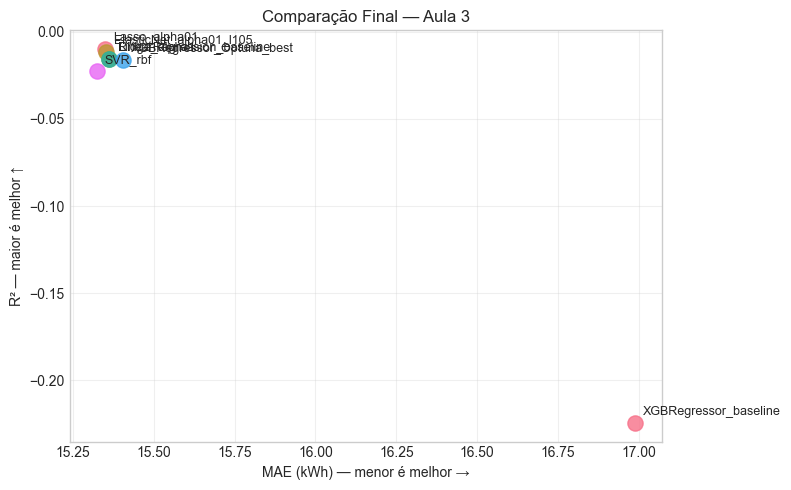


🥇 Melhor modelo da Aula 3: Lasso_alpha01
   R²   = -0.0099
   MAE  = 15.348 kWh
   RMSE = 19.530 kWh
   MAPE = 14.47%


In [31]:
# ============================================================
# COMPARAÇÃO VISUAL FINAL (R² × MAE)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in df_resultados.iterrows():
    ax.scatter(row["MAE"], row["R2"], s=120, alpha=0.8)
    ax.annotate(row["modelo"], (row["MAE"], row["R2"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("MAE (kWh) — menor é melhor →")
ax.set_ylabel("R² — maior é melhor ↑")
ax.set_title("Comparação Final — Aula 3")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparacao_final.png", dpi=100, bbox_inches="tight")
plt.show()

melhor_modelo = df_resultados.iloc[0]
print(f"\n🥇 Melhor modelo da Aula 3: {melhor_modelo['modelo']}")
print(f"   R²   = {melhor_modelo['R2']:+.4f}")
print(f"   MAE  = {melhor_modelo['MAE']:.3f} kWh")
print(f"   RMSE = {melhor_modelo['RMSE']:.3f} kWh")
print(f"   MAPE = {melhor_modelo['MAPE%']:.2f}%")


In [32]:
# ============================================================
# RUN "RESUMO" NO MLFLOW — CONCENTRA OS ARTEFATOS DA AULA
# ============================================================

with mlflow.start_run(run_name="Aula03_RESUMO"):
    mlflow.log_metric("melhor_r2",    melhor_modelo["R2"])
    mlflow.log_metric("melhor_mae",   melhor_modelo["MAE"])
    mlflow.log_metric("melhor_rmse",  melhor_modelo["RMSE"])
    mlflow.log_metric("melhor_mape",  melhor_modelo["MAPE%"] / 100)
    mlflow.log_param("melhor_modelo", melhor_modelo["modelo"])
    mlflow.log_param("n_modelos_treinados", len(resultados_todos))
    mlflow.log_param("target", TARGET)

    for artefato in [
        "resultados_aula03.csv",
        "comparacao_final.png",
        "ranking_modelos.png",
        "optuna_convergencia.png",
        "shap_global_bar.png",
        "shap_global_beeswarm.png",
        "shap_local_waterfall.png",
        "distribuicao_target.png",
        "correlacao_features_target.png",
        "scatter_top_features.png",
    ]:
        if os.path.exists(artefato):
            mlflow.log_artifact(artefato, "resumo_aula03")

print("✅ Run de resumo registrado no MLflow!")
print(f"🔗 Para visualizar todos os runs da Aula 3:")
print(f"   mlflow ui --backend-store-uri sqlite:///mlflow.db")
print(f"   Acesse: http://localhost:5000 → experimento 'aula03_regressao_producao'")


✅ Run de resumo registrado no MLflow!
🔗 Para visualizar todos os runs da Aula 3:
   mlflow ui --backend-store-uri sqlite:///mlflow.db
   Acesse: http://localhost:5000 → experimento 'aula03_regressao_producao'


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo

Praticar **pipelines de regressão**, **tuning de alpha** e **interpretação de resultados** modificando pontos pequenos no código desta aula.

### Tarefas

**Tarefa 1 — Tuning do `alpha` do Ridge**
- Teste 8 valores de `alpha` para o Ridge: `[0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]`.
- Para cada valor, treine um Pipeline e calcule `R²` e `MAE` no teste.
- Plote dois gráficos lado a lado: R² vs alpha (eixo x em log) e MAE vs alpha.
- Em qual alpha o R² atinge o pico? O que acontece com o modelo quando alpha é muito grande?

**Tarefa 2 — Trocar o Alvo para `production_count`**
- Repita o treinamento do `XGBRegressor` (pode usar os hiperparâmetros do `best` do Optuna) prevendo `production_count` em vez de `energy_usage_kwh`.
- Compare as métricas: o modelo consegue prever produção com a mesma qualidade que consegue prever consumo energético?
- Qual feature passa a ser a mais importante segundo o SHAP?

> 💡 **Dicas:** Use as células-esqueleto abaixo como ponto de partida. Substitua os trechos com `# SEU CÓDIGO AQUI`.


📊 Ridge_alpha0.001
   R²  = -0.0157
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


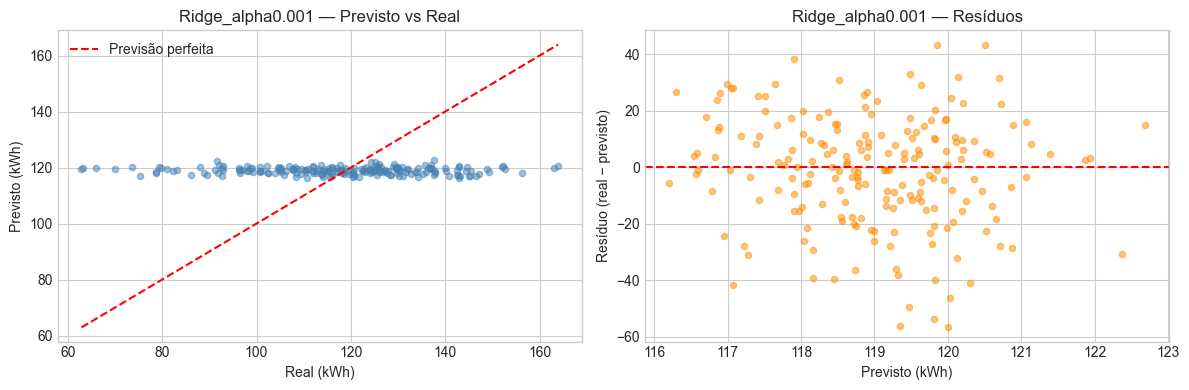

2026/04/27 21:49:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha0.01
   R²  = -0.0157
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


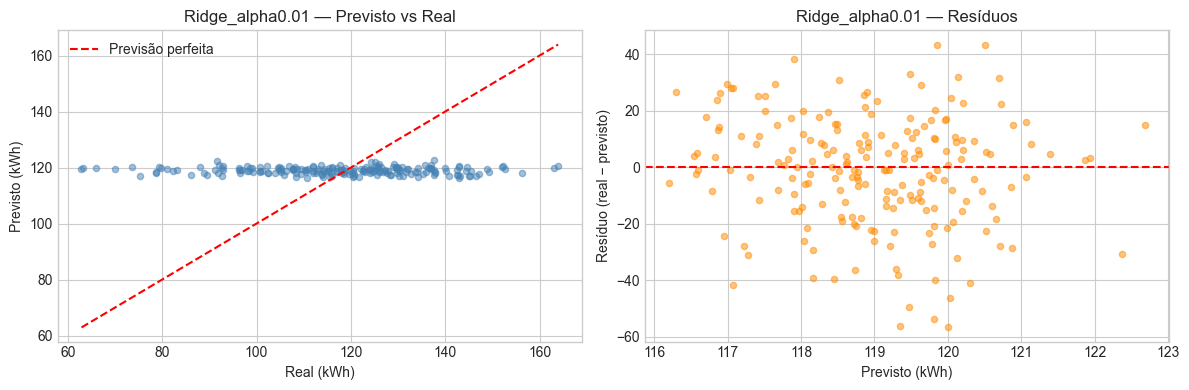

2026/04/27 21:49:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha0.1
   R²  = -0.0157
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


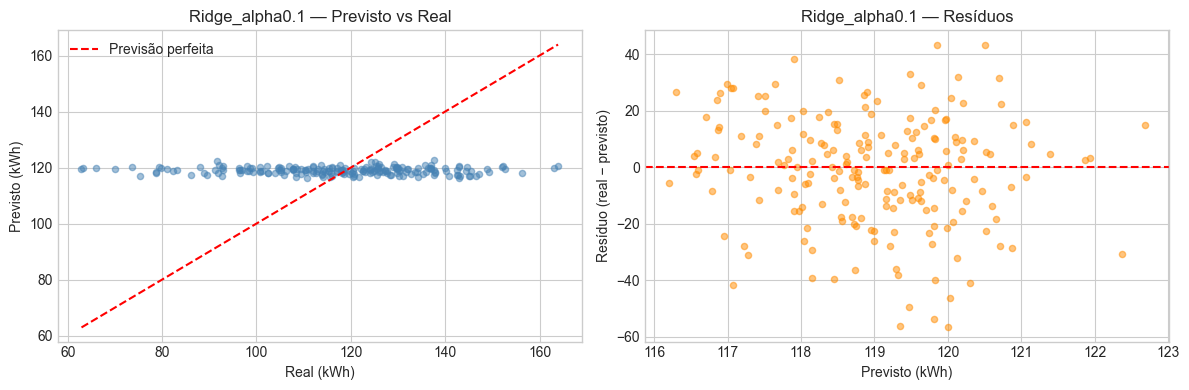

2026/04/27 21:49:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha0.5
   R²  = -0.0156
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


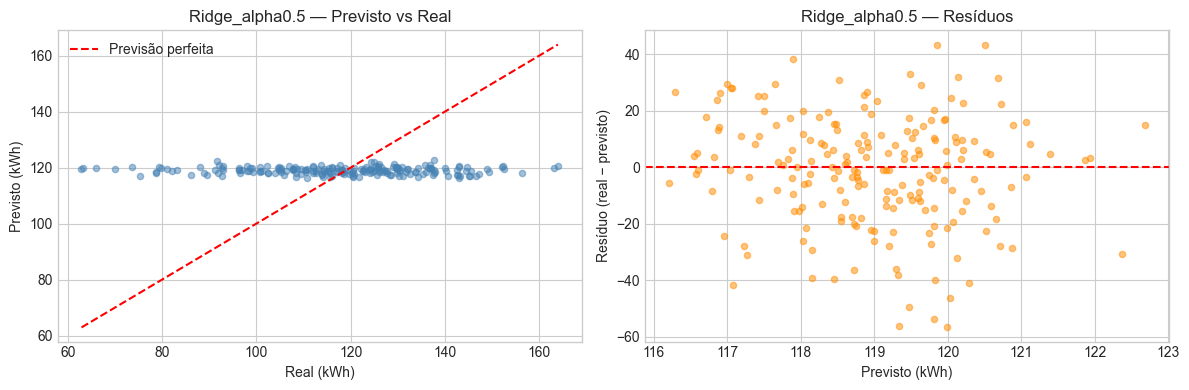

2026/04/27 21:49:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha1
   R²  = -0.0156
   MAE = 15.363 kWh
   RMSE= 19.585 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


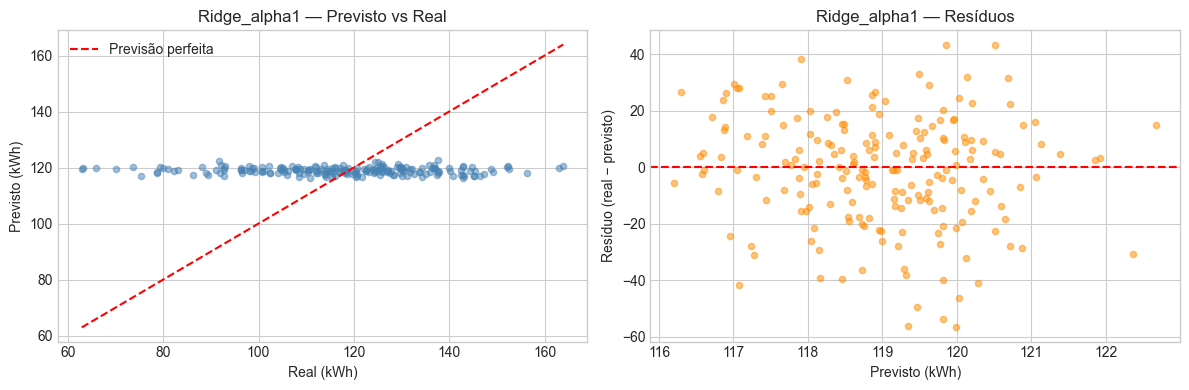

2026/04/27 21:49:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha5
   R²  = -0.0154
   MAE = 15.362 kWh
   RMSE= 19.583 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


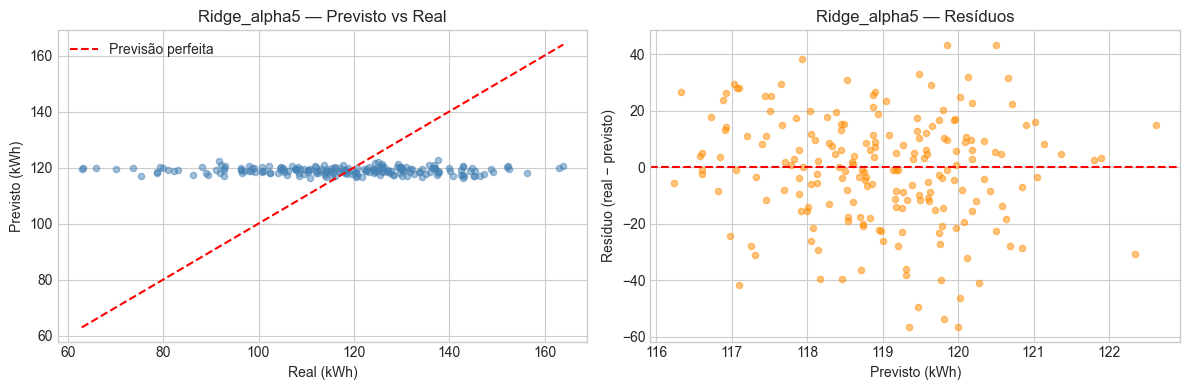

2026/04/27 21:49:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha10
   R²  = -0.0152
   MAE = 15.362 kWh
   RMSE= 19.581 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


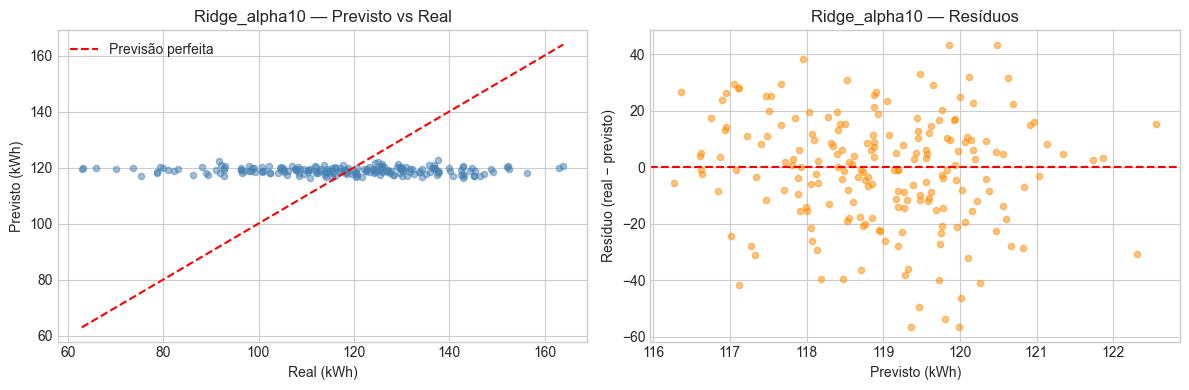

2026/04/27 21:49:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


📊 Ridge_alpha50
   R²  = -0.0139
   MAE = 15.359 kWh
   RMSE= 19.568 kWh
   MAPE= 14.48%
   ⏱️  Treino: 0.01s


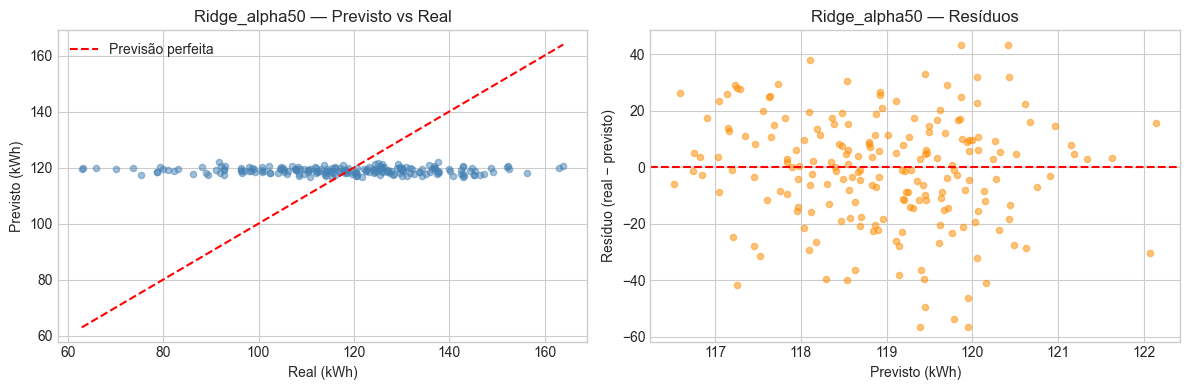

2026/04/27 21:50:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AttributeError: 'list' object has no attribute 'iterrows'

In [43]:
# ============================================================
# TAREFA 1 — Tuning do alpha do Ridge
# ============================================================
# Siga a mesma estrutura da seção 7.2 (Ridge_alpha1), variando
# apenas o alpha em um loop.

# ============================================================
# 7.2 — RIDGE (L2)
# ============================================================

valores = [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]

for x in range(len(valores)):
    a = valores[x]
    resultado_ridge = treinar_e_avaliar(
        nome_modelo = f"Ridge_alpha{a}",
        estimator = Ridge(alpha=a, random_state=RANDOM_STATE),
    )
    resultados_todos.append(resultado_ridge)


#     # SEU CÓDIGO AQUI — crie um Pipeline com Ridge(alpha=a)
# num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# numeric_pipeline = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median")),  # preenche nulos com mediana
#     ("scaler",  StandardScaler()),                  # padroniza (média 0, desvio 1)
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ("num", numeric_pipeline, num_cols),
# ])

    # SEU CÓDIGO AQUI — calcule R² e MAE


# SEU CÓDIGO AQUI — plote R² e MAE vs alpha (eixo x em log)

# ============================================================
# COMPARAÇÃO VISUAL FINAL (R² × MAE)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in resultados_todos.iterrows():
    ax.scatter(row["MAE"], row["R2"], s=120, alpha=0.8)
    ax.annotate(row["modelo"], (row["MAE"], row["R2"]),
                xytext=(6, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("MAE (kWh) — menor é melhor →")
ax.set_ylabel("R² — maior é melhor ↑")
ax.set_title("Comparação Final — Aula 3")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("comparacao_final.png", dpi=100, bbox_inches="tight")
plt.show()

melhor_modelo = df_resultados.iloc[0]
print(f"\n🥇 Melhor modelo da Aula 3: {melhor_modelo['modelo']}")
print(f"   R²   = {melhor_modelo['R2']:+.4f}")
print(f"   MAE  = {melhor_modelo['MAE']:.3f} kWh")
print(f"   RMSE = {melhor_modelo['RMSE']:.3f} kWh")
print(f"   MAPE = {melhor_modelo['MAPE%']:.2f}%")



📊 XGBRegressor prevendo 'production_count':
   R²   = -0.0061
   MAE  = 37.845
   RMSE = 43.814
   MAPE = 36.87%


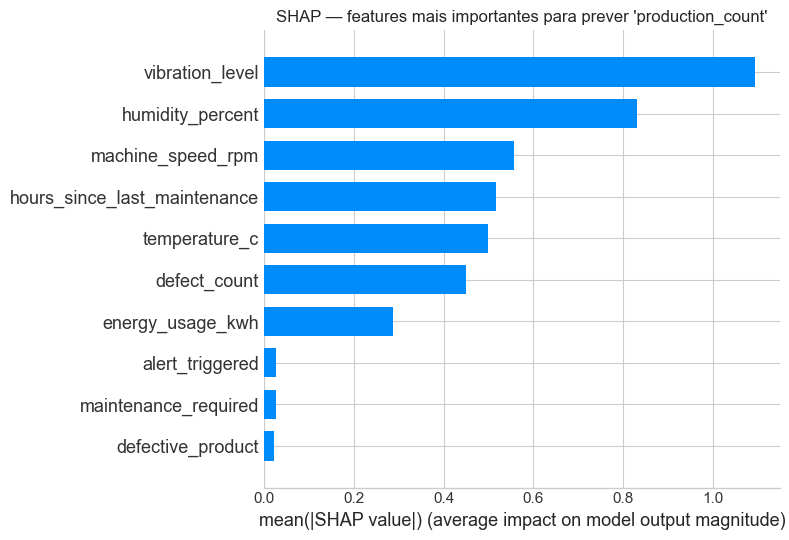


🏆 Feature mais importante para prever 'production_count': vibration_level
   (Compare com a feature mais importante para 'energy_usage_kwh' — é a mesma?)


In [ ]:
# ============================================================
# TAREFA 2 — Trocar o alvo para production_count
# ============================================================
# ATENÇÃO: mantenha X e y ORIGINAIS intactos nas variáveis globais.
# Aqui usamos variáveis com sufixo "_p" para não interferir no resto
# do notebook.


# SEU CÓDIGO AQUI — reutilize os melhores hiperparâmetros do Optuna


# SEU CÓDIGO AQUI — rode o SHAP no novo modelo e identifique a feature mais importante



### ✍️ Reflexão Final

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **Qual dos 6 regressores teve o maior R² para `energy_usage_kwh`? Foi um modelo linear ou não-linear?**
   - Resposta: *(escreva aqui)*

2. **A otimização bayesiana do Optuna conseguiu melhorar o `XGBRegressor` em relação ao baseline? Em quanto?**
   - Resposta: *(escreva aqui)*

3. **Segundo o SHAP, qual é a feature que mais impacta o consumo energético? Isso faz sentido do ponto de vista industrial?**
   - Resposta: *(escreva aqui)*

4. **Na indústria, entre MAE e RMSE, qual métrica você usaria para reportar o erro ao gestor da fábrica? Por quê?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!

Você completou a **Aula 3** e agora é capaz de:

- ✅ Enquadrar problemas de **regressão** e escolher métricas adequadas (R², MAE, RMSE, MAPE)
- ✅ Construir pipelines robustos com `Pipeline` + `ColumnTransformer`
- ✅ Treinar e comparar regressores lineares (Ridge, Lasso, ElasticNet) e não lineares (SVR, XGBRegressor)
- ✅ Fazer **otimização bayesiana** com Optuna integrada ao MLflow
- ✅ **Interpretar** previsões com SHAP (global e local)
- ✅ Versionar modelos em pasta padronizada para reuso nas próximas aulas

**Na próxima aula (Aula 4)**, mudamos de paradigma: saímos do **aprendizado supervisionado** e entramos no **aprendizado não supervisionado** — vamos detectar **anomalias em teares** usando Isolation Forest, LOF, One-Class SVM e DBSCAN. 🚀
